In [1]:
%load_ext autoreload
%autoreload 2

import os, sys, re
os.environ['KMP_DUPLICATE_LIB_OK']='True'
import numpy as np
import pandas as pd
import scanpy as sc
import torch
import time
import PINN
from PINN import reader, models, pl, tl
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from torchdiffeq import odeint

import matplotlib as mpl
import seaborn as sns
from matplotlib.patches import Patch


# main_dir = "/home/wz369/rds/hpc-work/PINN_dynamics"
main_dir = "/Users/weizhongzheng/Documents/python_project/PINN_dynamics/"
os.chdir(main_dir)

In [2]:
import palantir
# import cellrank as cr
import scvelo as scv

In [3]:
sc.settings.set_figure_params(frameon=False, dpi=50, figsize=(3,3))

# load data

In [4]:
# # load dataset

adata = sc.read_h5ad(f'data/ery_mk_Aug1.h5ad')
tompos = sc.read_h5ad(f'data/tom_pos.h5ad')

In [7]:
# known outlier
outlier_cbs = ['1079-SS2']
adata = adata[~adata.obs_names.isin(outlier_cbs)].copy()

In [8]:
adata.obs.query("`anno_man` == 'HSC'").sort_values('timepoint_tx_days')['timepoint_tx_days'].value_counts()

timepoint_tx_days
269    1170
112     704
161     518
76      498
27      386
49      281
7       130
3       105
12       67
Name: count, dtype: int64

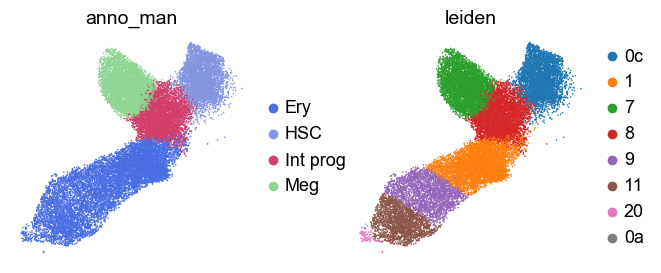

In [9]:
sc.pl.umap(adata, color=['anno_man','leiden'])

In [10]:
tompos.obs.query("`anno_man` == 'HSC'").sort_values('timepoint_tx_days')['timepoint_tx_days'].value_counts()

timepoint_tx_days
269    1943
112    1178
161     871
76      791
27      581
49      491
7       177
3       138
12       94
Name: count, dtype: int64

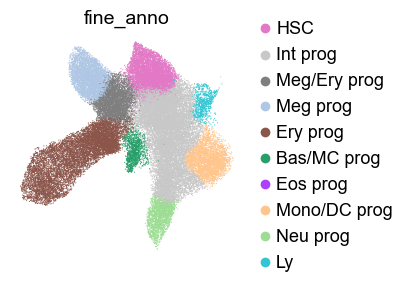

In [11]:
sc.pl.umap(tompos, color=['fine_anno'])

# load density transport results

In [12]:
from PINN.models import DT_analysis

## Exp configs

In [13]:
def check_non_zero_prop(TM):
    "For transport matrix at given time, check non zeros transport"

    ncell = TM.shape[0]
    TM_flat = TM.reshape(ncell,-1)
    nz =  np.sum(TM_flat.sum(axis=1) != 0) # count non zero cells

    return nz / ncell


In [194]:
# find all config files
config_dir = "logs/ery_mk_Aug1_multiscaled_n6/pde_params_tsense/"
configs = [file for file in os.listdir(config_dir) if file.endswith('.json')]

# load config for different runs
config_dict = {}
for js in configs:
    version = js.split("_")[0][1:] # after V
    config = PINN.ExperimentConfig(os.path.join(config_dir, js))
    config.from_json(os.path.abspath(os.path.join(config_dir, js)), main_dir)
    config_dict[version] = config

In [195]:
full_DS = reader.TwoTimpepoint_AnnDS(adata, split=None,  
                                     **config_dict['2'].dataset_config)


Dataset : Computing density :
	 `density_funs` not specified, default estimator gaussian kde
Dataset : Use KNN distances to compute the volume and rescale density
Dataset : smoothing KNN derived single-cell volume..
Dataset : all cells are used


cell type proportion summary detected
adding to  ct_prop property
2
(946, 100)
(945, 100)


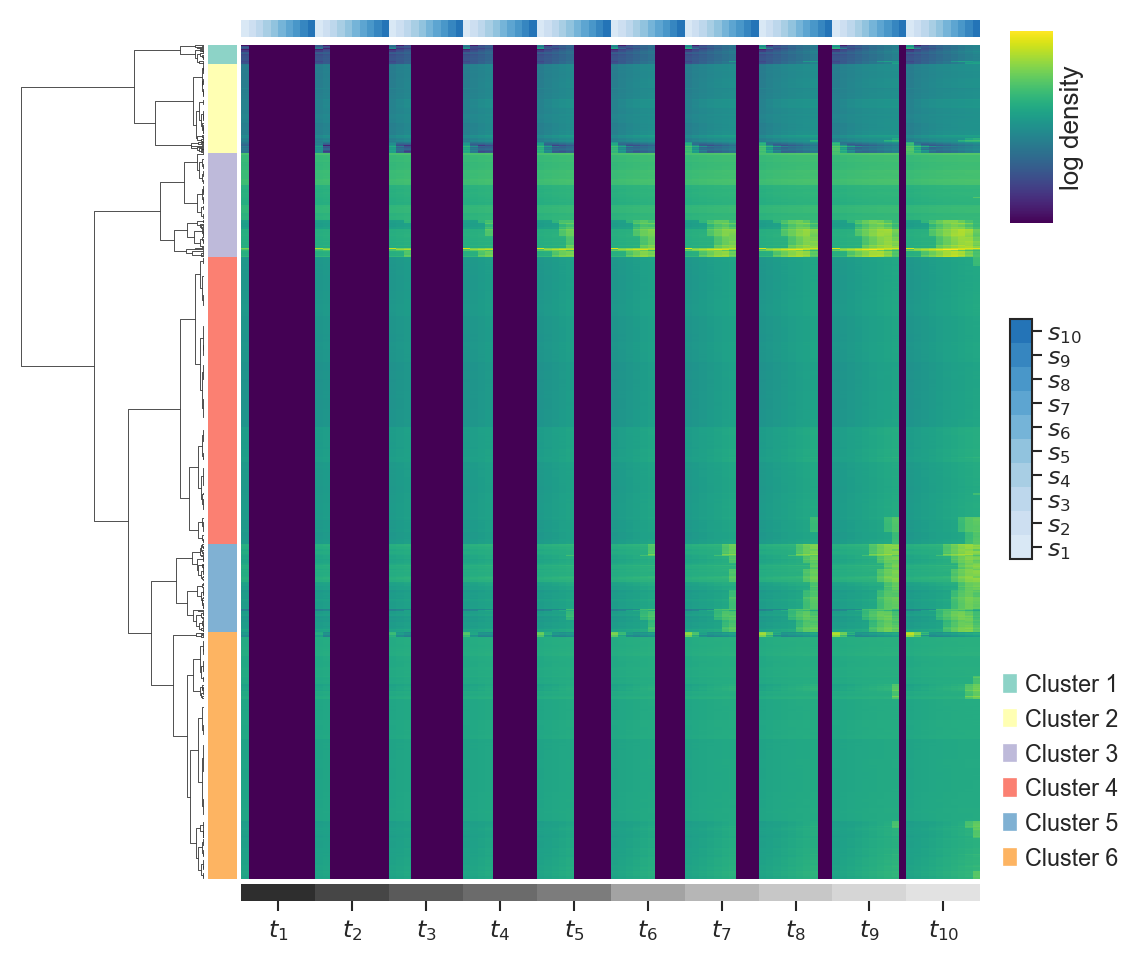

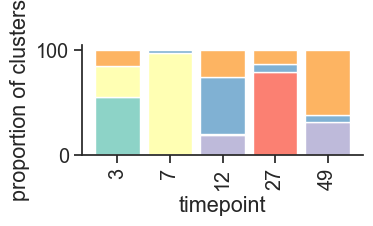

In [ ]:
# test new dt func : duds 

# find all config files
config_dir = "logs/ery_mk_Aug1_multiscaled_n6/pde_params_tsense/"
configs = [file for file in os.listdir(config_dir) if file.endswith('.json')]

# load config for different runs
config_dict = {}
for js in configs:
    version = js.split("_")[0][1:] # after V
    config = PINN.ExperimentConfig(os.path.join(config_dir, js))
    config.from_json(os.path.abspath(os.path.join(config_dir, js)), main_dir)
    config_dict[version] = config



Int_DT_dict = {}



# ticklabels for heat map
col_colorbar_tick_labels_x = [r"$s_1$", r"$s_2$", r"$s_3$", r"$s_4$", r"$s_5$", r"$s_6$", r"$s_7$", r"$s_8$", r"$s_9$", r"$s_{10}$"]
col_colorbar_tick_labels_y = [r"$t_1$", r"$t_2$", r"$t_3$", r"$t_4$", r"$t_5$", r"$t_6$", r"$t_7$", r"$t_8$", r"$t_9$", r"$t_{10}$"]

v = '2'

# for num_clusters in [5,6,7, 8]:

timepoints = ['0-4', '4-9',  '9-24', '24-46', '46-73' ]

v = '2'

for num_clusters in [6]:  
    
    # LOAD DT
    DT = DT_analysis(adata, f"results/ery_mk_Aug1_multiscaled_n6/pde_params_tsense_{v}/Density_transport", 
                     "Int prog")
    print(v)
    Tmap_all = np.concatenate([DT.TM_norm_dict[t] for t in timepoints], axis=0)

    # T_M_full = np.transpose(Tmap_all, axes=[0,2,1]).reshape(-1,100)
    T_M_full = Tmap_all.reshape(-1,100)

    # log 
    matrix_raw = T_M_full.copy()
    matrix_log = np.log(T_M_full+1e-20)
    T_M_full = matrix_log
    T_M_full = np.where(matrix_raw == 0, 0, matrix_log-matrix_log.min())
    print(T_M_full.shape)
    T_M_full = T_M_full[[i for i in range(T_M_full.shape[0]) if i not in [18]]]
    print(T_M_full.shape)
    # PLOT
    # if T_M_full.sum()>0:
    cluster_flat, reordered_indices, g = PINN.pl.truncated_clustermap(T_M_full, 
        num_clusters, 
        original_shape = (10,10),
        truncate_mode="level", p=4, 
        cluster_colors=None, 
        show_log=False,
        context_kws = {"figure.dpi":60},
        col_colorbar_size=(0.02, 0.25), 
        col_colorbar_location_x = (0.95, 0.4), 
        col_colorbar_location_y = (1.03, 0.4), 
        col_colorbar_tick_labels_x=col_colorbar_tick_labels_x,
        col_colorbar_tick_labels_y=col_colorbar_tick_labels_y,
        cbar_kws = {'label':'log density', 'ticks':[]}
        )
    # g.ax_col_colors.set_title(v)

    result_dir = 'results/ery_mk_Aug1_multiscaled_n6/pde_params_tsense_2'
    g.savefig(os.path.join(result_dir, f"DenTransport_MEP_c{num_clusters}.svg"), transparent=True, dpi=600)

    # CB LIST
    cb_list = []
    for t in timepoints:# , '109-158']:
        cb_list.append(DT.cb_dict[t])
    cb_list = np.concatenate(cb_list).tolist() 
    cb_list.remove(outlier_cbs[0])

    fig, axs = DT.cluster_proportion(cluster_flat, cb_list)
    # fig.savefig(os.path.join(result_dir, f"DenTransport_MEP_c{num_clusters}_cluster_proportion.svg"), transparent=True, dpi=600)
    # SAVE DT analysis
    sns.despine(ax=axs)
    Int_DT_dict[v] = DT
    

In [385]:
fig = plt.figure(figsize=(9,5), dpi=600)
ax  = fig.gca()



DT.cluster_proportion(cluster_flat, cb_list, ax=ax);


sns.despine(ax=ax)
ax.legend(ncol=2, fontsize=20)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
fig.savefig(os.path.join(result_dir, f"DenTransport_MEP_c{num_clusters}_cluster_proportion.svg"), transparent=True, dpi=600)




In [358]:
fig.savefig(os.path.join(result_dir, f"DenTransport_MEP_c{num_clusters}_cluster_proportion.svg"), transparent=True, dpi=600)

In [659]:
cb_list[np.where(cluster_flat == 3)[0]]

array(['1079-SS2'], dtype='<U40')

In [334]:
Tmap_all = np.concatenate([DT.TM_norm_dict[t] for t in timepoints], axis=0)
T_M_full = Tmap_all.reshape(-1,100)
T_M_full = T_M_full[[i for i in range(T_M_full.shape[0]) if i not in [18]]]

non_z_values = matrix_raw.flatten()[matrix_raw.flatten()!=0]
log_min = np.log(non_z_values).min() 
vmax = np.log(non_z_values).max()

# log 
matrix_raw = T_M_full.copy()
matrix_log = np.log(matrix_raw+1e-20)
T_M_full = matrix_log
T_M_full = np.where(matrix_raw == 0, 0, matrix_log-log_min)

In [335]:
log_min

np.float64(-6.6760654104684525)

(array([4.2525e+04, 2.0000e+00, 3.7000e+01, 4.7800e+02, 9.1500e+02,
        8.0280e+03, 3.6360e+04, 4.9900e+03, 1.1000e+03, 6.5000e+01]),
 array([ 0.        ,  1.0377062 ,  2.07541239,  3.11311859,  4.15082478,
         5.18853098,  6.22623717,  7.26394337,  8.30164956,  9.33935576,
        10.37706195]),
 <BarContainer object of 10 artists>)

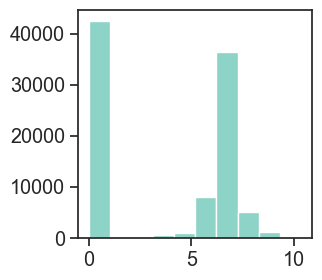

In [336]:
plt.hist(T_M_full.flatten())

In [ ]:
Tmap_all = np.concatenate([DT.TM_norm_dict[t] for t in timepoints], axis=0)
T_M_full = Tmap_all.reshape(-1,100)
T_M_full = T_M_full[[i for i in range(T_M_full.shape[0]) if i not in [18]]]

non_z_values = matrix_raw.flatten()[matrix_raw.flatten()!=0]
log_min = np.log(non_z_values).min() 
vmax = np.log(non_z_values).max()

# log 
matrix_raw = T_M_full.copy()
matrix_log = np.log(matrix_raw+1e-20)
T_M_full = matrix_log
T_M_full = np.where(matrix_raw == 0, 0, matrix_log-log_min)

In [435]:
vmin, vmax

(np.float64(43.05028331105399), np.float64(47.5617136740836))

Text(-1, 0, 'scaled log density')

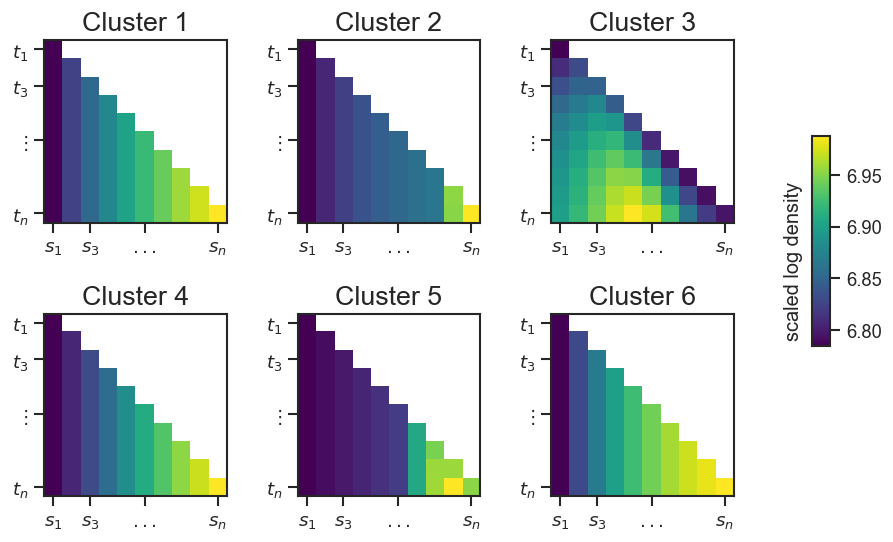

In [504]:
T_M_full.flatten()
# DT = DT_analysis(adata, f"results/ery_mk_Aug1_multiscaled_n6/pde_params_tsense_2/Density_transport", 
#                      "Int prog")
# Tmap_all = np.concatenate([DT.TM_norm_dict[t] for t in timepoints], axis=0)

TM_cluster = {}
vmax = 0.1
vmin = 99
for i in range(1,7):
    # TM_ci = np.mean(T_M_full[cluster_flat == i], axis=0)
    # TM_cluster[str(i)] = TM_ci.reshape(10,10)
    N_TM = np.sum(cluster_flat == i)
    TM_ci = T_M_full[cluster_flat == i][np.random.randint(0, N_TM)]
    TM_cluster[str(i)] = TM_ci.reshape(10,10)

    vmax = np.max([vmax, np.quantile(TM_ci, 0.95).item()])
    vmin = np.min([vmin, TM_ci[TM_ci!=0].min().item()])
nrow = 2
ncol = 3

fig, axs = plt.subplots(nrow, ncol, figsize=(2.5*ncol, 2.5*nrow), dpi=60, 
                        frameon=False, gridspec_kw={"hspace":0.5, 'wspace':0.3})
axs = axs.flatten()

it = 0
for cluster, TM in TM_cluster.items():

    T_values = T_M_full[np.logical_and(T_M_full!=0, ~np.isnan(T_M_full))]
    

    # PINN.pl.plot_tmap(TM, ax=axs[ it], log=False, 
    #              vmax=np.log(T_values.max()), vmin=np.log(T_values.min()/5))
    
    trui = np.triu_indices_from(TM, k=1)
    TM[trui] = np.nan
    ms = axs[it].matshow(TM, cmap='viridis' )#, vmin=vmin*1.5, vmax=vmax*0.98)

    t = adata.uns['pop']['t'][it]
    tp1 = adata.uns['pop']['t'][it+1]

    axs[it].set_title(f"Cluster {cluster}", fontsize=16)

    axs[it].set_yticks([0,2, 5, 9])
    axs[it].set_yticklabels([r"$t_1$", r"$t_3$", r"$\vdots$", r"$t_n$"])
    
    axs[it].tick_params(top=False, labeltop=False, bottom=True, labelbottom=True)
    # axs[it].set_xticks(np.arange(0,10,2))
    # axs[it].set_xticklabels([r"$s_1$", r"$s_3$", r"$s_5$", r"$s_7$", r"$s_9$"])
    axs[it].set_xticks([0,2, 5, 9])
    axs[it].set_xticklabels([r"$s_1$", r"$s_3$", r"$...$", r"$s_n$"])
    

    it += 1

cax = fig.add_axes([1.04, 0.4, 0.02, 0.35], label="Density")
plt.colorbar(ms, cax=cax)
cax.set_title('scaled log density', rotation=90, x=-1, y=0)
# axs[-1].axis("off")


In [505]:
fig.savefig(os.path.join(result_dir, "density_transfer_random_example_matrix_2.svg"), transparent=True, dpi=600)

In [345]:
fig.savefig(os.path.join(result_dir, "density_transfer_example_matrix.svg"), transparent=True, dpi=600)

In [343]:
result_dir

'results/ery_mk_Aug1_multiscaled_n6/pde_params_tsense_2'

In [353]:
density_df = []
for i in range(1,7):
    df = pd.DataFrame(T_M_full[cluster_flat == i].flatten(), columns=['log_density'])
    df['cluster'] = i
    density_df.append(df)
density_df = pd.concat(density_df, axis=0)

In [405]:
density_df.to_csv(os.path.join(result_dir, 'cluster_TM_df.csv'))

'results/ery_mk_Aug1_multiscaled_n6/pde_params_tsense_2'

In [ ]:
result_dir = 'results/ery_mk_Aug1_multiscaled_n6/pde_params_tsense_2'
density_df = pd.read_csv(os.path.join(result_dir, 'cluster_TM_df.csv'))

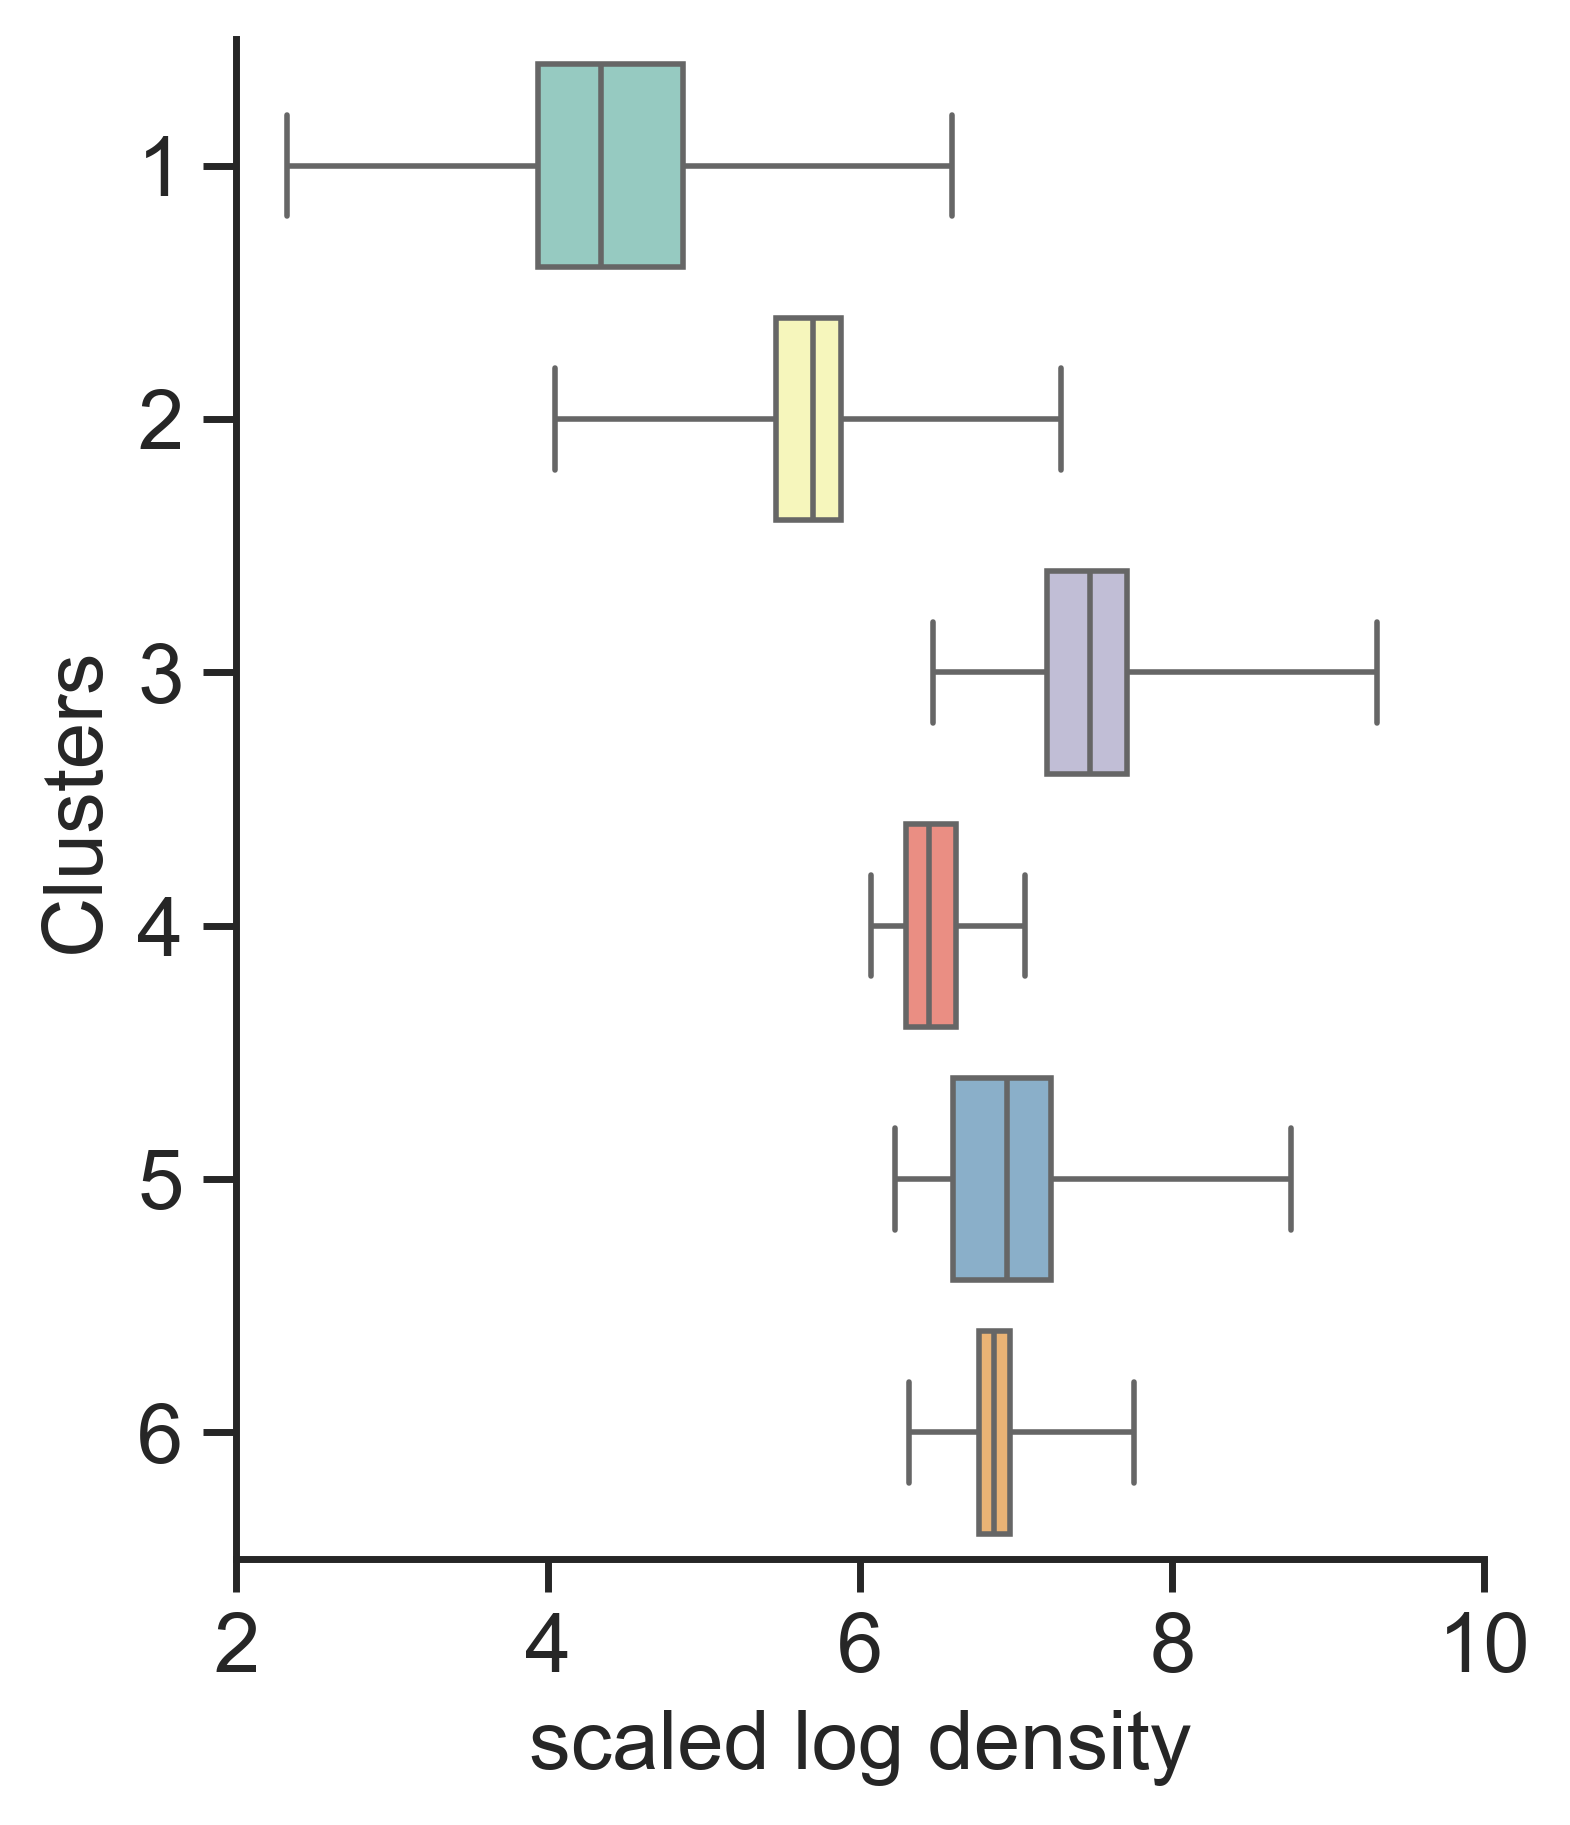

In [431]:
sns.set_theme(style='ticks')
result_dir = 'results/ery_mk_Aug1_multiscaled_n6/pde_params_tsense_2'
density_df = pd.read_csv(os.path.join(result_dir, 'cluster_TM_df.csv'))

fig = plt.figure(figsize=(4,5), dpi=200)
ax  = fig.gca()


sns.boxplot(density_df.query('`log_density`!=0'), 
            y='cluster', x='log_density', hue='cluster',
             palette='Set3', legend=None,
             ax=ax, whis=[1,99], showfliers=False,
             orient='h'
            )

ax.set_xlim(2, 10)
ax.set_xlabel('scaled log density', fontsize=15)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=15)
ax.set_ylabel('Clusters', fontsize=15)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=15)
sns.despine(ax=ax)
# ax.legend(ncol=3)

fig.savefig(os.path.join(result_dir, 'DT_log_density_box_h.svg'), dpi=600, transparent=True)

In [707]:
np.nanmax(TM),  np.nanmin(TM)

(np.float64(46.608406327481724), np.float64(46.087472465007565))

In [ ]:
cb_list = []
for t in ['0-4', '4-9',  '9-24', '24-46', '46-73', '73-109', '109-158']:
    cb_list.append(DT.cb_dict[t])

cb_list = np.concatenate(cb_list)

cell type proportion summary detected
adding to  ct_prop property
2
(969, 100)


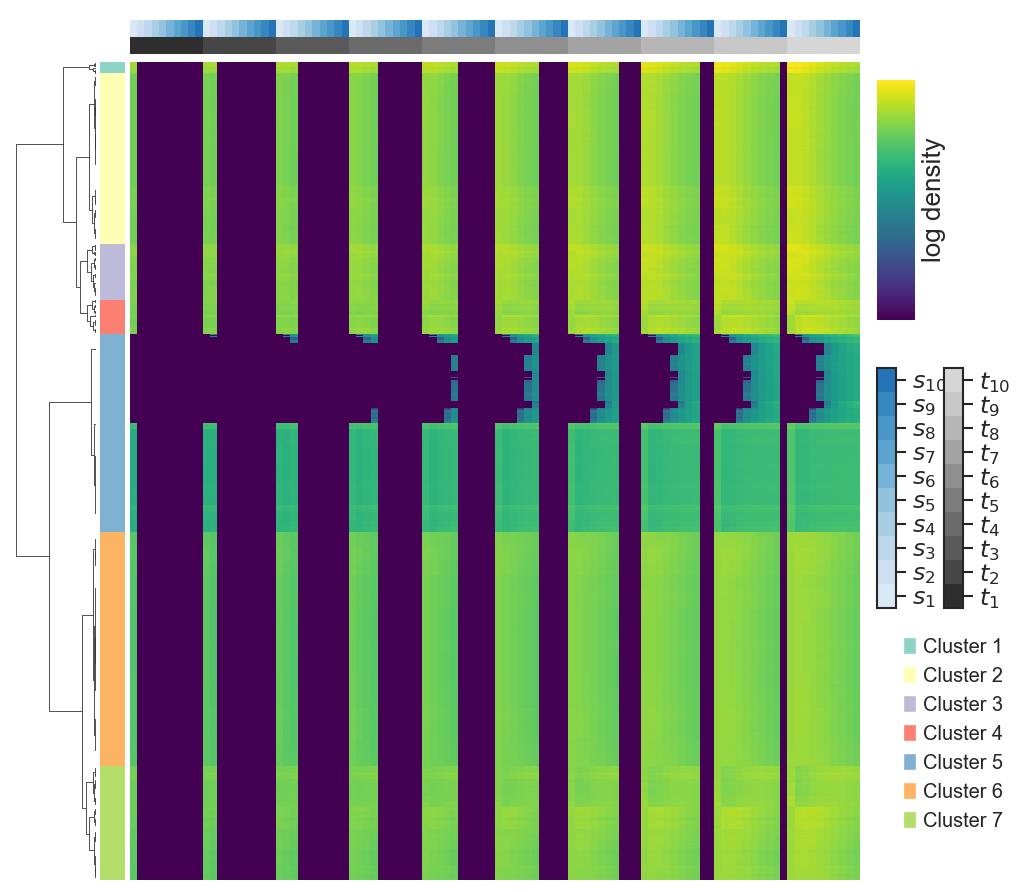

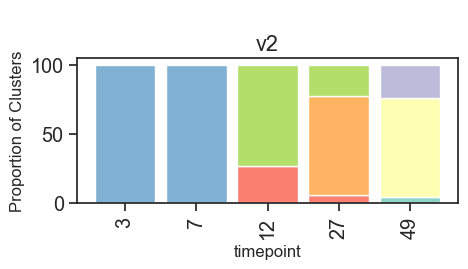

In [518]:
# test new dt func : duds 



HSC_DT_dict = {}



# ticklabels for heat map
col_colorbar_tick_labels_x = [r"$s_1$", r"$s_2$", r"$s_3$", r"$s_4$", r"$s_5$", r"$s_6$", r"$s_7$", r"$s_8$", r"$s_9$", r"$s_{10}$"]
col_colorbar_tick_labels_y = [r"$t_1$", r"$t_2$", r"$t_3$", r"$t_4$", r"$t_5$", r"$t_6$", r"$t_7$", r"$t_8$", r"$t_9$", r"$t_{10}$"]

# num_clusters = 7
# for v in config_dict:

v = '2'

for num_clusters in [7]:    
    # LOAD DT
    DT = DT_analysis(adata, f"results/ery_mk_Aug1_multiscaled_n6/pde_params_tsense_{v}/Density_transport", 
                     "HSC")
    print(v)

    # CB LIST
    order_days = ['0-4', '4-9',  '9-24', '24-46', '46-73']
    
    cb_list = []
    for t in ['0-4', '4-9',  '9-24', '24-46', '46-73']:#, '73-109', '109-158']:
        cb_list.append(DT.cb_dict[t])
    cb_list = np.concatenate(cb_list)

    Tmap_all = np.concatenate([DT.TM_norm_dict[t] for t in order_days], axis=0)
    # T_M_full = np.transpose(Tmap_all, axes=[0,2,1])
    T_M_full = Tmap_all.reshape(-1,100)
    print(T_M_full.shape)


    # PLOT
    if T_M_full.sum()>0:
        cluster_flat, reordered_indices, g = PINN.pl.truncated_clustermap(T_M_full, 
            num_clusters, 
            original_shape = (10,10),
            truncate_mode="level", p=4, 
            cluster_colors=None, 
            show_log=True,
            context_kws = {"figure.dpi":60},
            col_colorbar_size=(0.02, 0.25), 
            col_colorbar_location_x = (0.93, 0.35), 
            col_colorbar_location_y = (1., 0.35), 
            col_colorbar_tick_labels_x=col_colorbar_tick_labels_x,
            col_colorbar_tick_labels_y=col_colorbar_tick_labels_y,
            cbar_kws = {'label':'log density', 'ticks':[]}
            )
        
    c4s = cluster_flat[cluster_flat == 4]
    # cb_list.append(
    #     adata.obs[celltype].loc[c4s.index].to_numpy()
    # )
    
    

    adata.obs['HSC_cluster_flat'] = 'na'
    named_cluster_flats = ['HSC_c%s'%c for c in cluster_flat]
    adata.obs.loc[cb_list, 'HSC_cluster_flat'] = named_cluster_flats


    sns.set_theme(font_scale=1.3, style='ticks', palette='Set3')
    fig, ax = PINN.pl.obs_composition(
                adata[cb_list], 
                'timepoint_tx_days', 'HSC_cluster_flat', 
                figkws={'figsize':[5,3.5]},
                legend_kws={"handles":[], "frameon":False,  "fontsize":13 ,'ncol':3, "bbox_to_anchor":(0.05, 1.4), "loc":'upper left', }
                )
    ax.set_title(f"v{v}")

    ax.set_xlabel("timepoint", fontsize=12)
    ax.set_ylabel("Proportion of Clusters", fontsize=12)


    # SAVE DT analysis
    HSC_DT_dict[v] = DT

2


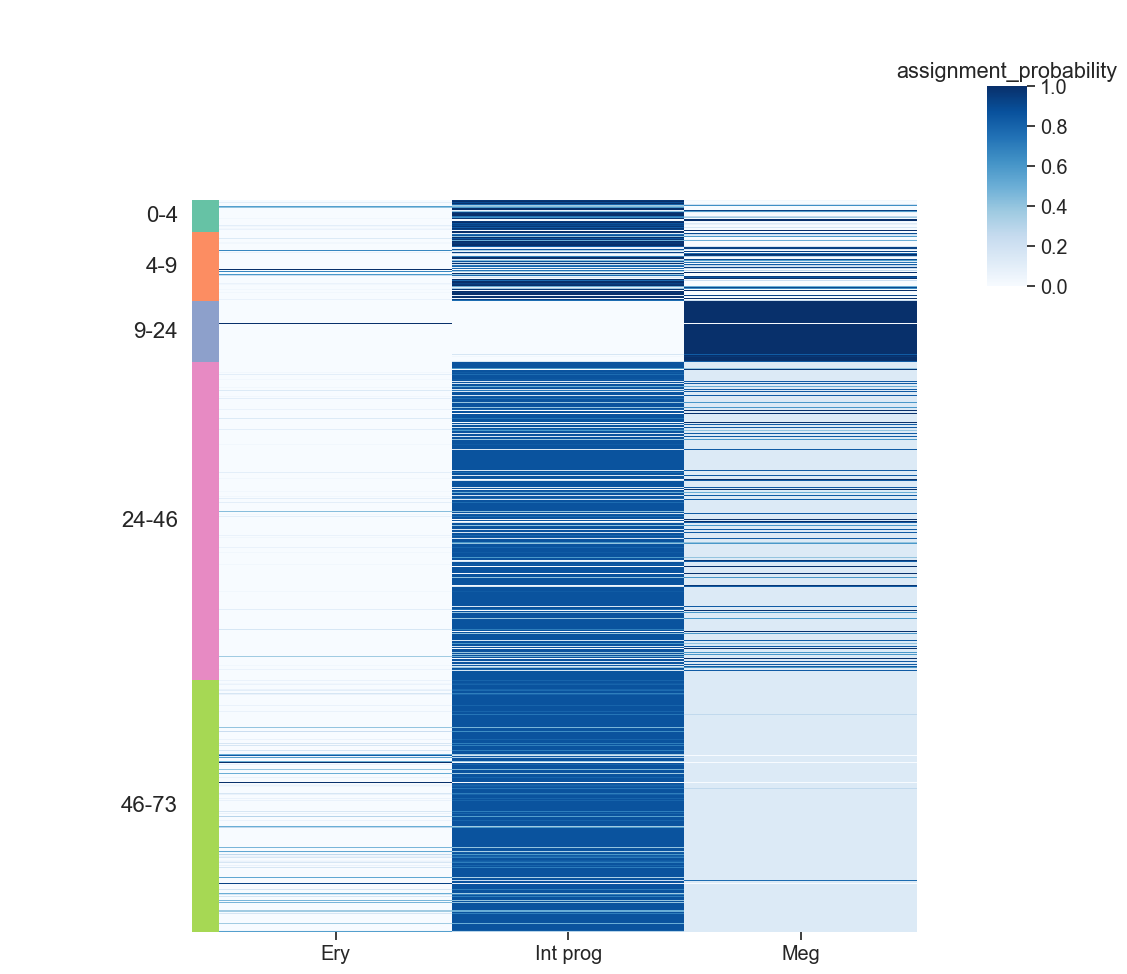

In [19]:
import time
for v,DT in Int_DT_dict.items():
    print(v)
    g = DT.heatmap_cell_proportions(['Ery', 'Int prog', 'Meg'],
                                     step=-3,
                                     cbar_pos = [1,0.7,0.04,0.2],
                                     cmap='Blues'
                                     )
    g

# aggregated density

In [20]:
from matplotlib import cm

In [346]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np

def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    new_cmap = colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

cmap = plt.get_cmap('bone_r')
new_cmap = truncate_colormap(cmap, 0.01, 0.6)
# new_cmap = 'Blues'

In [347]:
realt_mapper = dict(zip(['4-9', '46-73', '24-46', '9-24', '0-4'], ['7-12', '49-76', '27-49', '12-27', '3-7']))

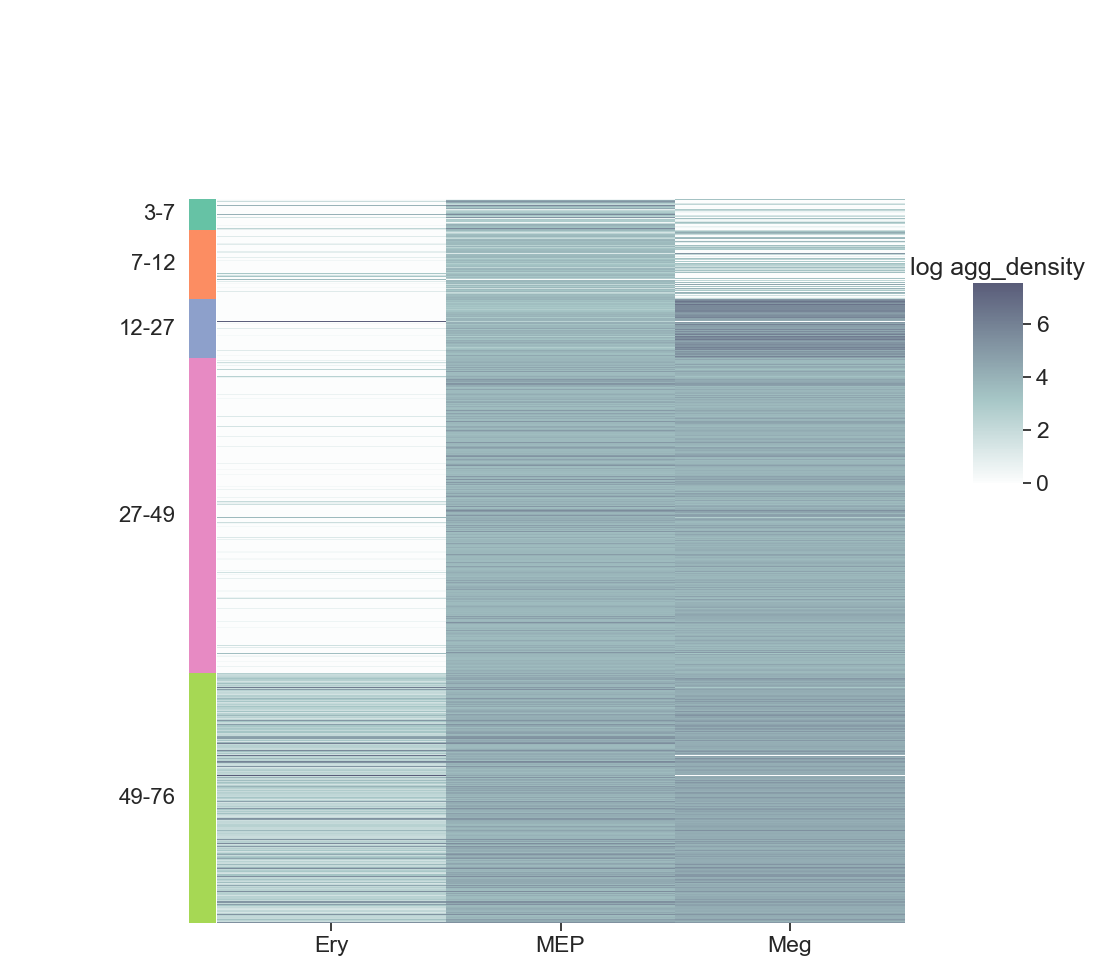

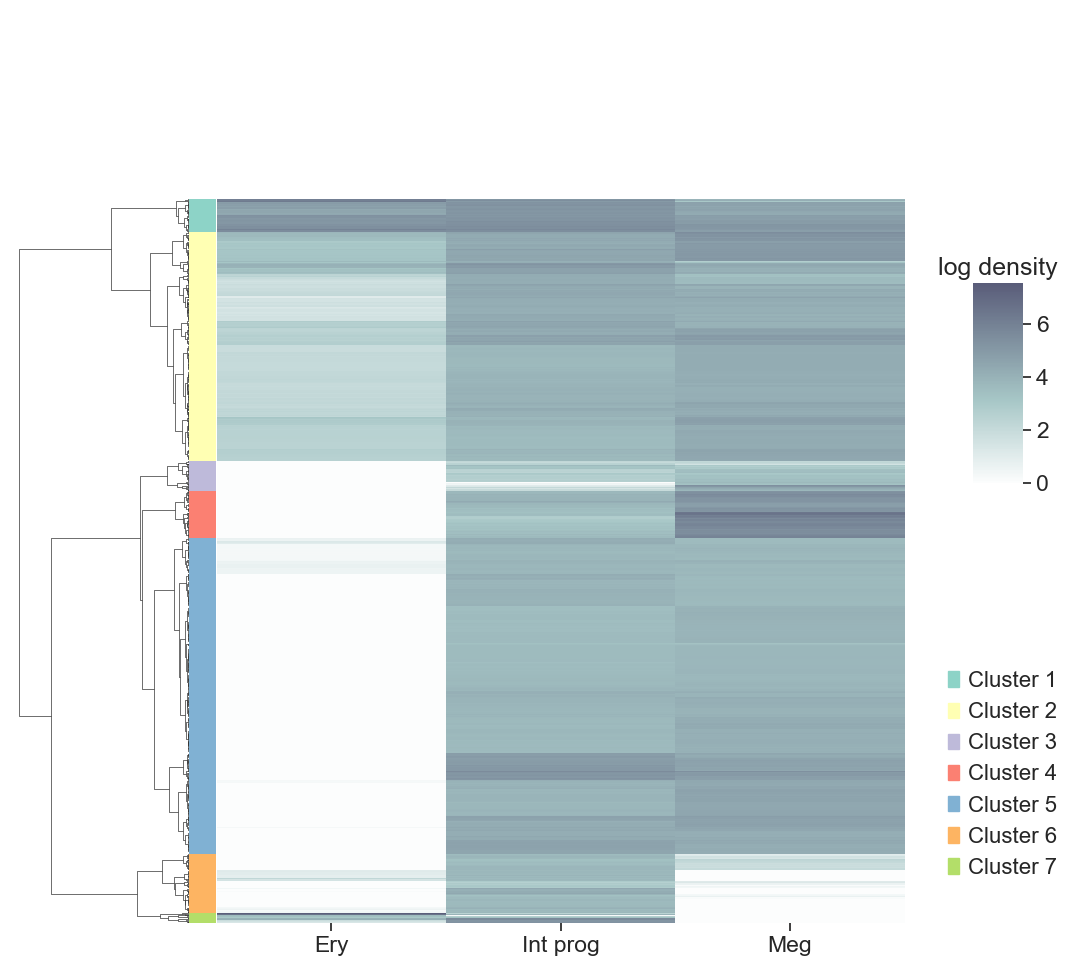

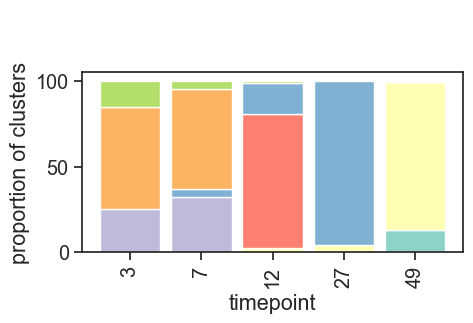

In [351]:
DT = Int_DT_dict['2']

log_normalize = True
n_clusters = 7
celltypes = ['Ery', 'Int prog', 'Meg']
value='agg_density'
cmap = new_cmap

DT.density_by_celltype_step(celltypes=celltypes, step=-1, norm=True)
DT.agg_density = DT.agg_density.loc[cb_list].copy()
DT.agg_density['Day'] = DT.agg_density.Day.map(realt_mapper)

sns.set_theme(style='ticks', font_scale=1.5)
g = DT.heatmap_cell_proportions(celltypes=celltypes, value=value,  log_normalize=log_normalize, cmap=cmap,
                                cbar_pos=[0.99, 0.5, 0.05,0.2])
# g.ax_heatmap.set_yticks([])
# g.ax_heatmap.set_title("transported density grouped by celltype", pad=30, fontsize=20)
g.ax_heatmap.set_xticklabels(['Ery', 'MEP', 'Meg'])


celltypes = ['Ery','Int prog','Meg']
clusters, row_linkage, _ = DT.hierarchical_clustering(celltypes=celltypes, value=value,  log_normalize=log_normalize,  n_clusters=n_clusters)


g2 = DT.clustermap(
                clusters, row_linkage,
                celltypes=celltypes, value=value,  
                log_normalize=log_normalize, cmap=cmap,
                cbar_pos=[0.99, 0.5, 0.05,0.2],
                figsize=(10,10),
                )

cellbarcodes = DT.agg_density.index
figprop, axs = DT.cluster_proportion(clusters, cellbarcodes)




result_dir = 'results/ery_mk_Aug1_multiscaled_n6/pde_params_tsense_2'
log_name = ['', 'log '][log_normalize]

g.savefig(os.path.join(result_dir, f'{value}_celltype_timemap_c{n_clusters}{log_name}.svg'), 
          dpi=600, transparent=True)

# g2.savefig(os.path.join(result_dir, f'{value}_celltype_clustermap_c{n_clusters}{log_name}.svg'), 
#           dpi=600, transparent=True)

# figprop.savefig(os.path.join(result_dir, f'{value}_celltype_cluster_bar_c{n_clusters}{log_name}.svg'), 
#           dpi=600, transparent=True)

# Sanky plot

In [34]:
DT_save = f"results/ery_mk_Aug1_multiscaled_n6/pde_params_tsense_2/Density_transport"
result_dir = 'results/ery_mk_Aug1_multiscaled_n6/pde_params_tsense_2'

HSC_DT = DT_analysis(adata, DT_save,  "HSC")
MEP_DT = DT_analysis(adata, DT_save,  "Int prog")

cell type proportion summary detected
adding to  ct_prop property
cell type proportion summary detected
adding to  ct_prop property


In [18]:
celltypes = ["Ery",  "Meg", "Int prog"]
first_step= MEP_DT.density_by_celltype_step(celltypes=celltypes, step=0, norm=False)
last_step= MEP_DT.density_by_celltype_step(celltypes=celltypes, step=-1, norm=False)

In [19]:
first_step_sum = first_step.groupby('Day').agg("mean").reset_index()
first_step_sum['step'] = 1
first_step_sum.rename({'Int prog':"MEP"}, axis=1, inplace=True)
first_step_sum = first_step_sum.set_index("Day").rename({'Int prog':"MEP"},axis=1)
first_step_sum

,Ery,Meg,MEP,step
Day,,,,
0-4,3.383703e-08,2.163984e-07,0.000005,1
24-46,1.240245e-06,1.182890e-04,0.000363,1
4-9,8.385345e-07,1.971037e-06,0.000031,1
46-73,6.099397e-06,2.385477e-04,0.000692,1
9-24,1.166847e-06,5.664863e-05,0.000181,1


In [20]:
last_step_sum = last_step.groupby('Day').agg("mean").reset_index()
last_step_sum['step'] = 10
last_step_sum = last_step_sum.set_index("Day").rename({'Int prog':"MEP"},axis=1)
last_step_sum

,Ery,Meg,MEP,step
Day,,,,
0-4,0.000004,0.000021,0.000190,10
24-46,0.000029,0.004160,0.004046,10
4-9,0.000013,0.000229,0.000370,10
46-73,0.002470,0.005945,0.005459,10
9-24,0.000023,0.006032,0.000987,10


## matplotlib sankey

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.sankey import Sankey

## unnormalized sankey

In [22]:
import pandas as pd
import plotly.graph_objects as go

In [23]:
tompos.obs['fine_anno'].cat.categories

Index(['HSC', 'Int prog', 'Meg/Ery prog', 'Meg prog', 'Ery prog',
       'Bas/MC prog', 'Eos prog', 'Mono/DC prog', 'Neu prog', 'Ly'],
      dtype='object')

In [24]:
tompos.uns['fine_anno_colors']

array(['#E278C6', '#C8C8C8', '#7f7f7f', '#AFC7E5', '#8C554A', '#279F6A',
       '#AD40FC', '#FFC58B', '#9BDD91', '#31C6D3'], dtype=object)

In [387]:
timeponts = ['0-4', '4-9', '9-24', '24-46', '46-73']
celltypes = ["MEP", "Ery",  "Meg"]

label = []
for i, time in enumerate(adata.uns['pop']['t'][:6]):
    for s, source_cell in enumerate(celltypes):
        label.append(f'{source_cell} D{time}')

color = ['#7f7f7f', '#8C554A',  '#AFC7E5'] * 6

source = []
target = []
value = []
for i, time in enumerate(timeponts):
    for t, target_cell in enumerate(celltypes):
        for s, source_cell in enumerate(celltypes):
        
            
            source.append(i*3 + s)
            target.append((i+1)*3 + t)

            if source_cell == 'MEP':
                prop = last_step_sum.loc[time, target_cell].item() / last_step_sum.loc[time, celltypes].sum().item()
                flow = last_step_sum.loc[time][target_cell] - first_step_sum.loc[time][source_cell] * prop
                # flow = first_step_sum.loc[time][target_cell] * prop #- first_step_sum.loc[time][source_cell] * prop
                value.append(flow)
                
            elif source_cell == target_cell:
                value.append(1e-20)
            
            else:
                value.append(0)

            

In [388]:
len(source), len(target), len(value)

(45, 45, 45)

In [389]:
flow_df = pd.DataFrame(
    np.array([source, target, value]).T,
    columns=['source', 'target', 'value']
)

In [390]:
y_loc = []
x_loc = [] 
for i in range(6):
    pad = (i + 1)* 0.1
    y_loc.extend(
        [0.6-np.random.random()*0.1, 0.6-pad, 0.6+pad]
    )
    x_loc.extend(
        [i*0.2, i*0.2, i*0.2]
    )

In [398]:
fig = go.Figure(data=[go.Sankey(
    node = dict(
      pad = 20,
      thickness = 20,
      line = dict(color = "black", width = 0.5),
      label = label,
      color = color,
      x = x_loc,
      y = y_loc,
      
    ),
    link = dict(
      source = source, # indices correspond to labels, eg A1, A2, A1, B1, ...
      target = target,
      value = value
  ))])

fig.update_layout(font_size=16)
fig.show()

In [399]:
fig.write_image(os.path.join(result_dir, 'unnormalized_sankey.svg'))

# normalized sankey

In [186]:
source = []
target = []
value = []
for i, time in enumerate(timeponts):
    for t, target_cell in enumerate(celltypes):
        for s, source_cell in enumerate(celltypes):
            
            if source_cell == 'MEP':
                prop = last_step_sum.loc[time, target_cell].item() / last_step_sum.loc[time, celltypes].sum().item()
                value.append(prop)
            else:
                if source_cell == target_cell:
                    value.append(1e-20)
                else:
                    continue
            source.append(i*3 + s)
            target.append((i+1)*3 + t)

            

In [187]:
fig = go.Figure(data=[go.Sankey(
    node = dict(
      pad = 20,
      thickness = 15,
      line = dict(color = "black", width = 0.5),
      label = label,
      color = color,
      x = x_loc,
      y = [0.551675792537951, 0.09999999999999998, 1.1] * 6
    ),
    link = dict(
      source = source, # indices correspond to labels, eg A1, A2, A1, B1, ...
      target = target,
      value = value
  ))])

fig.update_layout(title_text="Basic Sankey Diagram", font_size=10)
fig.show()

In [188]:
fig.write_image(os.path.join(result_dir, 'normalized_sankey.svg'))

## full dataset sankey 

In [224]:
model = PINN.models.pde_params.load_from_checkpoint(config_dict['2'].find_lastest_ckpt())
int = PINN.tl.density_shortterm_simulation(model, full_DS, timepoints=adata.uns['pop']['t'][:6]-3)
u_int = np.concatenate([full_DS.u_b[[0]], int], axis=0)

0it [00:00, ?it/s]

simulating from timepoint 0 to 4
simulating from timepoint 4 to 9
simulating from timepoint 9 to 24
simulating from timepoint 24 to 46
simulating from timepoint 46 to 73


In [198]:
celltype_labels = full_DS.adata.obs.anno_man.replace("Int prog", "MEP")

In [199]:
DT_save = f"results/ery_mk_Aug1_multiscaled_n6/pde_params_tsense_2/Density_transport"
HSC_DT = DT_analysis(adata, DT_save,  "HSC")

# HSC
HSC_agg_dist = HSC_DT.density_by_celltype_step(celltypes=[ 'HSC','Int prog','Ery','Meg'], step=-1, norm=False)
HSC_agg_u_sum = HSC_agg_dist.groupby('Day').agg("mean").reset_index()
HSC_agg_u_sum.rename({'Int prog':"MEP"}, axis=1, inplace=True)
HSC_agg_u_sum = HSC_agg_u_sum.set_index("Day").rename({'Int prog':"MEP"},axis=1)
HSC_agg_u_sum = HSC_agg_u_sum.apply(lambda row : row / row.sum() , axis=1)

# MEP
MEP_DT = DT_analysis(adata, DT_save,  "Int prog")

MEP_agg_dist = MEP_DT.density_by_celltype_step(celltypes=['Int prog', 'Ery', 'Meg'], step=-1, norm=False)
MEP_agg_u_sum = MEP_agg_dist.groupby('Day').agg("mean").reset_index()
MEP_agg_u_sum.rename({'Int prog':"MEP"}, axis=1, inplace=True)
MEP_agg_u_sum = MEP_agg_u_sum.set_index("Day").rename({'Int prog':"MEP"},axis=1)
MEP_agg_u_sum = MEP_agg_u_sum.apply(lambda row : row / row.sum() , axis=1)

cell type proportion summary detected
adding to  ct_prop property
cell type proportion summary detected
adding to  ct_prop property


In [249]:
u_int_pop = u_int / u_int.sum(axis=1, keepdims=True)
sim_u_df = pd.DataFrame(u_int_pop.T, columns=[f'Day{t}' for t in adata.uns['pop']['t'][:6]])
sim_u_df['celltype'] = celltype_labels.values
sim_u_df = sim_u_df.groupby(['celltype',]).agg('sum')

In [253]:
sim_u_df#.loc['Ery', 'Day3']

,Day3,Day7,Day12,Day27,Day49,Day76
celltype,,,,,,
Ery,0.019378,0.103286,0.246896,0.258088,0.512167,0.366351
HSC,0.507191,0.372339,0.248861,0.295796,0.099547,0.149265
MEP,0.361696,0.306840,0.320641,0.251299,0.285672,0.262832
Meg,0.111735,0.217534,0.183603,0.194817,0.102614,0.221552


In [329]:
sim_u_df.T.index

Index(['Day3', 'Day7', 'Day12', 'Day27', 'Day49', 'Day76'], dtype='object')

In [255]:
MEP_agg_u_sum

,MEP,Ery,Meg
Day,,,
0-4,0.885804,0.016614,0.097581
24-46,0.491352,0.003478,0.505170
4-9,0.605327,0.020820,0.373852
46-73,0.393444,0.178028,0.428528
9-24,0.140205,0.003279,0.856516


In [310]:
timeponts = adata.uns['pop']['t'][:6]
periods = ['0-4', '4-9', '9-24', '24-46', '46-73']
celltypes = ["HSC", "MEP", "Ery",  "Meg"]
n_ct = len(celltypes)

label = []
for i, time in enumerate(adata.uns['pop']['t'][:6]):
    for s, source_cell in enumerate(celltypes):
        label.append(f'{source_cell} Day{time}')

color = ['#E278C6', '#7f7f7f', '#8C554A',  '#AFC7E5'] * 6


source = []
target = []
value = []
for i, time in enumerate(timeponts[:-1]):

    period = periods[i]

    for s, source_cell in enumerate(celltypes):
            
        for t, target_cell in enumerate(celltypes):
        
            if source_cell == 'HSC':

                p_source = sim_u_df.loc[source_cell, f'Day{time}'].item()
                p_transit = HSC_agg_u_sum.loc[period, target_cell].item()

                value.append(p_source*p_transit)
                

            elif source_cell == 'MEP':
                if target_cell == 'HSC':
                    continue
                else:

                    p_source = sim_u_df.loc[source_cell, f'Day{time}'].item()
                    p_transit = MEP_agg_u_sum.loc[period, target_cell].item()

                value.append(p_source*p_transit)
                
            elif source_cell == target_cell:
                p_source = sim_u_df.loc[source_cell, f'Day{time}'].item()
                value.append(p_source)
            else:
                continue
            
            source.append(i*n_ct + s)
            target.append((i+1)*n_ct + t)

In [320]:
alpha = 0.4

def hex_to_rgb(value):
    value = value.lstrip('#')
    lv = len(value)
    rgb = [str(int(value[i:i + lv // 3], 16)) for i in range(0, lv, lv // 3)] 
    rgba = f'rgba({",".join(rgb)}, {alpha})'
    return rgba

rgb_color = [hex_to_rgb(hexcode) for hexcode in color]
link_color = np.array(rgb_color)[source]

In [321]:
label = np.array(label)
transit_data = pd.DataFrame({'source':label[source], 'target' :label[target], 'link':value})
transit_data['start'] = transit_data['source'].apply(lambda x: int(x.split('Day')[-1]))
transit_data['end'] = transit_data['target'].apply(lambda x: int(x.split('Day')[-1]))

transit_data.head()

,source,target,link,start,end
0,HSC Day3,HSC Day7,0.306755,3,7
1,HSC Day3,MEP Day7,0.191440,3,7
2,HSC Day3,Ery Day7,0.008892,3,7
3,HSC Day3,Meg Day7,0.000104,3,7
4,MEP Day3,MEP Day7,0.320392,3,7


In [322]:
transit_data.groupby('start')['link'].sum()

start
3     1.0
7     1.0
12    1.0
27    1.0
49    1.0
Name: link, dtype: float64

In [323]:
transit_data.groupby('end')['link'].sum()

end
7     1.0
12    1.0
27    1.0
49    1.0
76    1.0
Name: link, dtype: float64

In [324]:
fig = go.Figure(data=[go.Sankey(
    node = dict(
      pad = 10,
      thickness = 15,
      line = dict(color = "black", width = 0.5),
      label = label,
      color = color,
    #   x = x_loc,
    #   y = [0.551675792537951, 0.09999999999999998, 1.1] * 6
    ),
    link = dict(
      source = source, # indices correspond to labels, eg A1, A2, A1, B1, ...
      target = target,
      value = value,
      color = link_color,
  ))])

fig.update_layout(title_text="Basic Sankey Diagram", font_size=10)
fig.show()

# Result for `ery_mk_Aug1_multiscaled_n6`

<font size=1>  
 
```python

# test new dt func : duds 

# find all config files
config_dir = "logs/ery_mk_Aug1_multiscaled_n6/pde_params_tsense/"
configs = [file for file in os.listdir(config_dir) if file.endswith('.json')]

# load config for different runs
config_dict = {}
for js in configs:
    version = js.split("_")[0][1:] # after V
    config = PINN.ExperimentConfig(os.path.join(config_dir, js))
    config.from_json(os.path.abspath(os.path.join(config_dir, js)), main_dir)
    config_dict[version] = config

num_clusters = 5

Int_DT_dict = {}



# ticklabels for heat map
col_colorbar_tick_labels_y = [r"$s_1$", r"$s_2$", r"$s_3$", r"$s_4$", r"$s_5$", r"$s_6$", r"$s_7$", r"$s_8$", r"$s_9$", r"$s_{10}$"]
col_colorbar_tick_labels_x = [r"$t_1$", r"$t_2$", r"$t_3$", r"$t_4$", r"$t_5$", r"$t_6$", r"$t_7$", r"$t_8$", r"$t_9$", r"$t_{10}$"]

v = '2'

# for num_clusters in [5,6,7, 8]:

timepoints = ['0-4', '4-9',  '9-24', '24-46', '46-73' ]

for v in config_dict:
    
    # LOAD DT
    DT = DT_analysis(adata, f"results/ery_mk_Aug1_multiscaled_n6/pde_params_tsense_{v}/Density_transport", 
                     "Int prog")
    print(v)
    Tmap_all = np.concatenate([DT.TM_norm_dict[t] for t in timepoints], axis=0)

    T_M_full = np.transpose(Tmap_all, axes=[0,2,1]).reshape(-1,100)
    print(T_M_full.shape)

    # log 
    matrix_raw = T_M_full.copy()
    matrix_log = np.log(T_M_full+1e-20)
    T_M_full = np.where(matrix_raw == 0, 0, matrix_log-matrix_log.min())

    # PLOT
    # if T_M_full.sum()>0:
    cluster_flat, reordered_indices, g = PINN.pl.truncated_clustermap(T_M_full, 
        num_clusters, 
        original_shape = (10,10),
        truncate_mode="level", p=4, 
        cluster_colors=None, 
        show_log=False,
        context_kws = {"figure.dpi":60},
        col_colorbar_size=(0.02, 0.25), 
        col_colorbar_location_x = (0.93, 0.35), 
        col_colorbar_location_y = (1., 0.35), 
        col_colorbar_tick_labels_x=col_colorbar_tick_labels_x,
        col_colorbar_tick_labels_y=col_colorbar_tick_labels_y,
        cbar_kws = {'label':'log density', 'ticks':[]}
        )
    g.ax_col_colors.set_title(v)
    g.fig

    # CB LIST
    cb_list = []
    for t in timepoints:# , '109-158']:
        cb_list.append(DT.cb_dict[t])
    cb_list = np.concatenate(cb_list)

    adata.obs['HSC_cluster_flat'] = 'na'
    named_cluster_flats = ['Cluster%s'%c for c in cluster_flat]
    adata.obs.loc[cb_list, 'HSC_cluster_flat'] = named_cluster_flats


    sns.set_theme(font_scale=1.3, style='ticks', palette='Set3')
    with plt.rc_context({"figure.dpi":100, "figure.figsize":(4,4)}):
        fig, ax = PINN.pl.obs_composition(
                    adata[cb_list], 
                    'timepoint_tx_days', 'HSC_cluster_flat', 
                    figkws={'figsize':[5,4]},
                    legend_kws={"handles":[], "frameon":False,  "fontsize":13 ,'ncol':3, "bbox_to_anchor":(0.05, 1.4), "loc":'upper left', }
                    )
        ax.set_title(v)

    ax.set_xlabel("timepoint", fontsize=12)
    ax.set_ylabel("Proportion of Clusters", fontsize=12)


    # SAVE DT analysis
    Int_DT_dict[v] = DT
``` 
  
</font>

**HSC for n6**

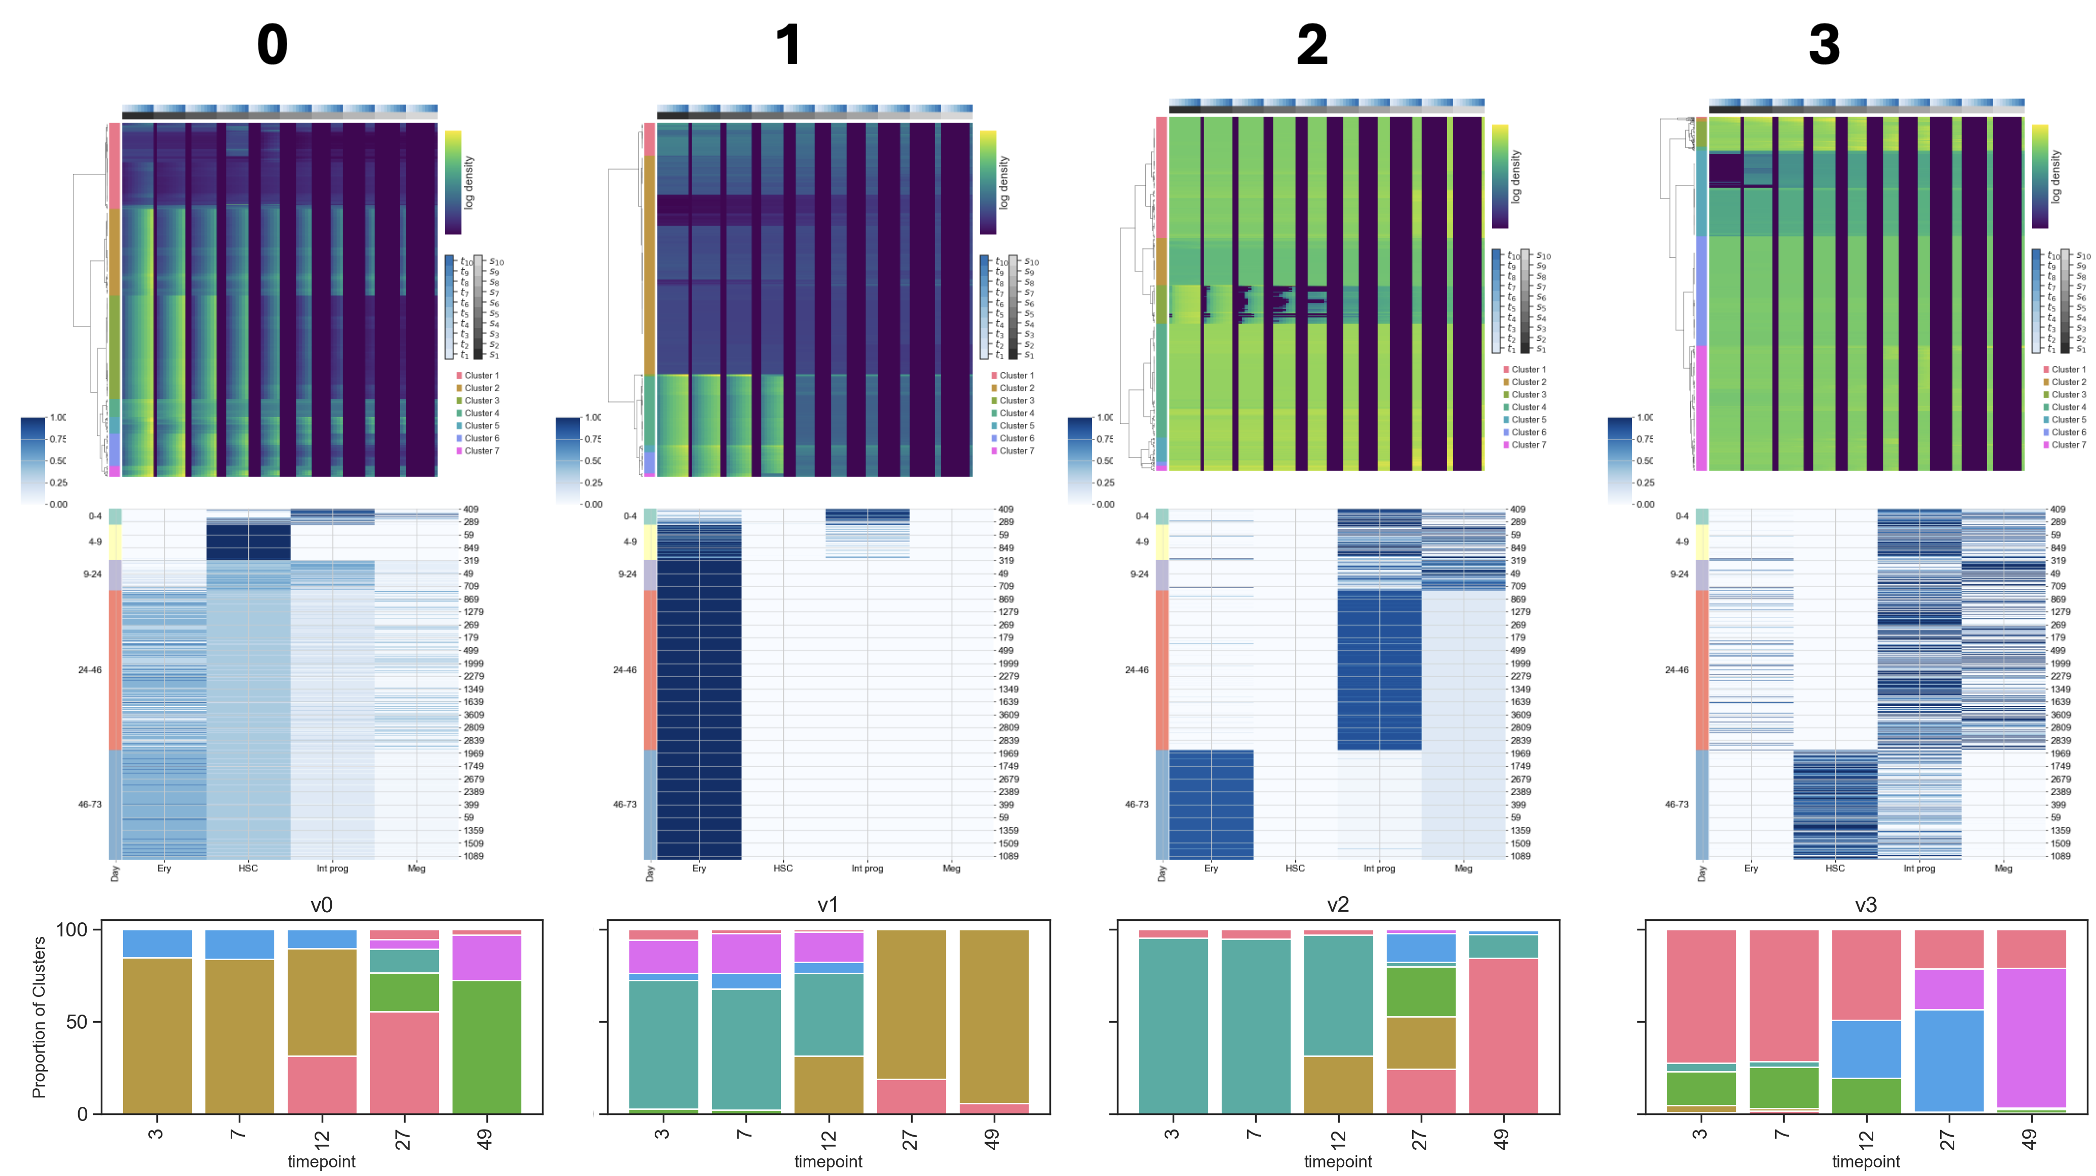

**Int prog for n6**
  
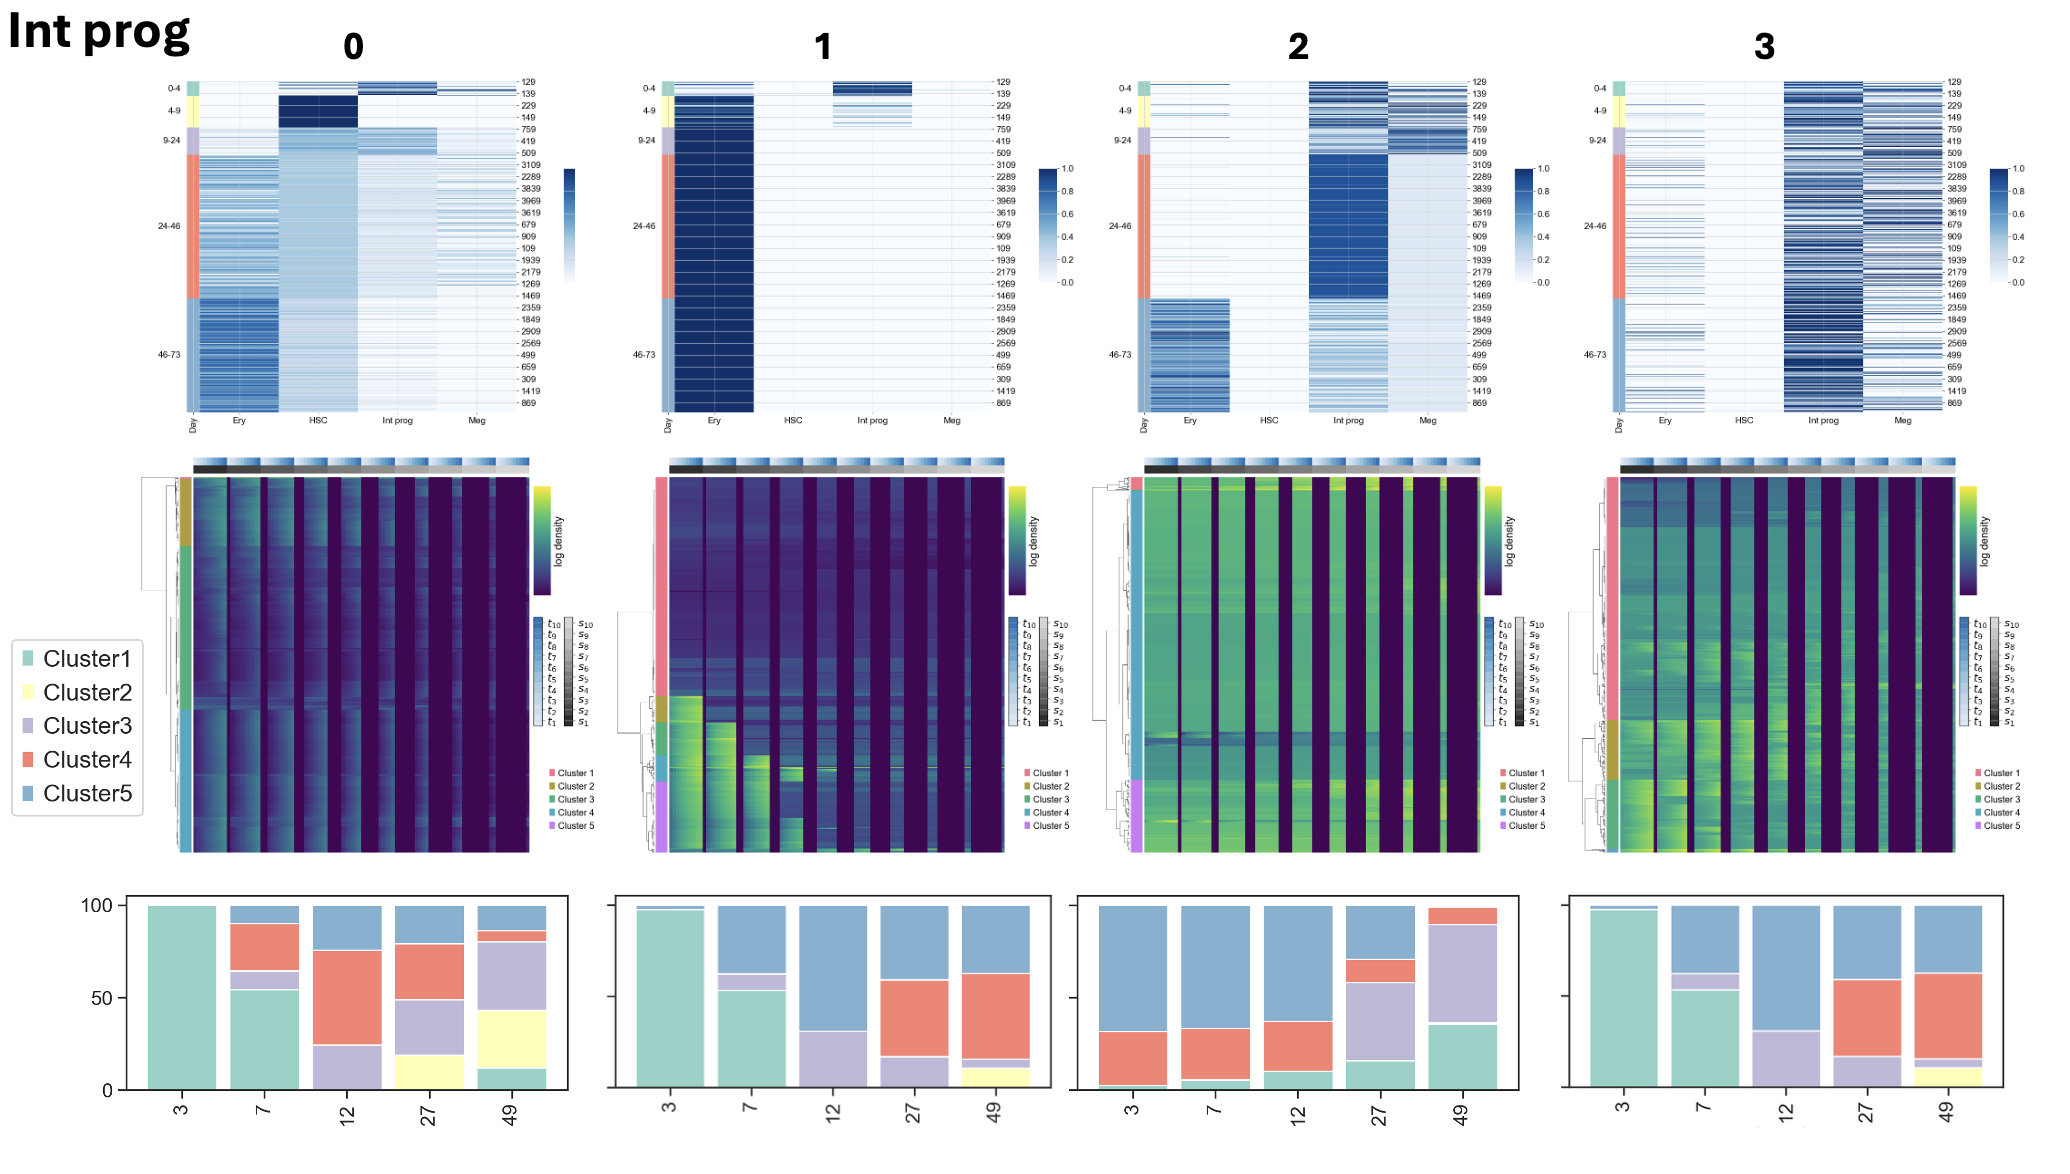

# Density transport and celltype for every s along the trajectory